In [ ]:
# import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score

)

In [ ]:
# load dataset
df = pd.read_csv("/content/preprocessed_plant_disease_dataset.csv")
print("Dataset loaded succesfully.")
print("Shape: df.shape")
display(df.head())

Dataset loaded succesfully.
Shape: df.shape


,temperature,humidity,rainfall,soil_pH,disease_present
0,27.483571,33.215053,0.572758,4.975875,1
1,28.238443,34.026189,16.095303,6.316734,1
2,32.615149,41.104180,20.311015,6.164949,0
3,23.829233,51.971785,11.851323,8.482468,0
4,23.829315,32.289578,2.058564,5.727685,0


In [ ]:
# Inspect dataset
print("Dataset Information")
print("=" * 50)
print("Shape:, df.shape")

print("Data types:")
print(df.dtypes)

print("Summary statistics:")
print(df.describe)

print("Duplicate rows")
print(df.duplicated().sum())

print("Missing values:")
print(df.isnull().sum)

Dataset Information
Shape:, df.shape
Data types:
temperature        float64
humidity           float64
rainfall           float64
soil_pH            float64
disease_present      int64
dtype: object
Summary statistics:
<bound method NDFrame.describe of       temperature   humidity   rainfall   soil_pH  disease_present
0       27.483571  33.215053   0.572758  4.975875                1
1       28.238443  34.026189  16.095303  6.316734                1
2       32.615149  41.104180  20.311015  6.164949                0
3       23.829233  51.971785  11.851323  8.482468                0
4       23.829315  32.289578   2.058564  5.727685                0
...           ...        ...        ...       ...              ...
9694    31.505510  81.939137  22.406822  5.862952                1
9695    15.008275  86.886833  10.503881  4.070539                0
9696    21.473416  81.891770  13.426869  7.101583                0
9697    27.478828  88.567649   9.719659  7.732620                0
9698    28.

In [ ]:
# Define feature
features = ["temperature", "humidity", "rainfall", "soil_pH"]

target = "disease_present"

x = df[features]
y = df[target]

print("Features:")
print(features)

print("\nTarget:")
print(target)


Features:
['temperature', 'humidity', 'rainfall', 'soil_pH']

Target:
disease_present


Disease Rate : 23.56%
Healthy=0, Disease=1


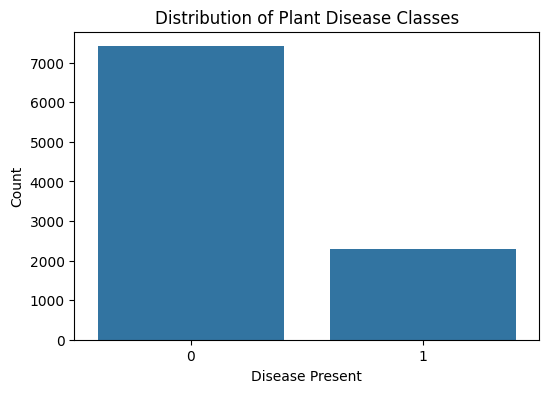

In [ ]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target)
plt.title("Distribution of Plant Disease Classes")
plt.xlabel("Disease Present")
print(f"Disease Rate : {df['disease_present'].mean()*100:.2f}%")
print("Healthy=0, Disease=1")
plt.ylabel("Count")
plt.show()

In [ ]:
# Train/Test Split (80/20, stratified)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 7759
Testing samples: 1940


In [ ]:
# Model-1: Gaussian Naive Bayes
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)

print("Naive Bayes model trained successfully.")

# Predict
nb_predictions = nb_model.predict(x_test_scaled)
print("\nNaive Bayes predictions completed.")

Naive Bayes model trained successfully.

Naive Bayes predictions completed.


Accuracy: 0.7701030927835052
Precision: 0.7300011245754978
Recall: 0.7701030927835052
F1: 0.7224941677486492

Accuracy: 77.01%
Precision: 73.00%
Recall: 77.01%
F1: 72.25%
   precision    recall  f1-score
0   0.789503  0.953473  0.863775
1   0.536913  0.175055  0.264026


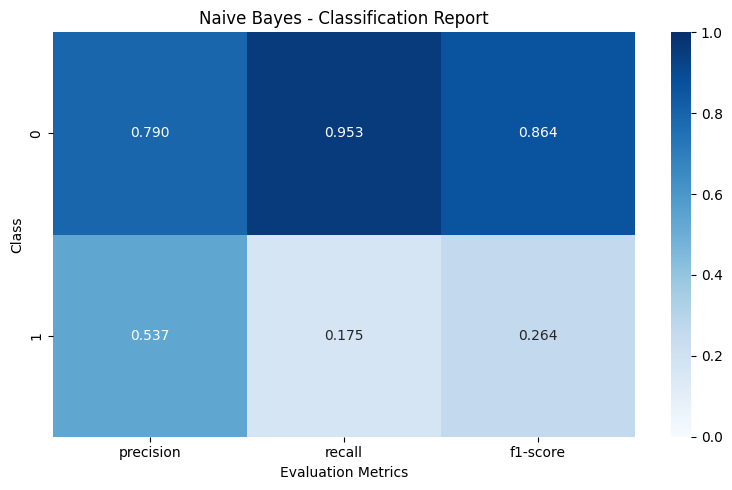

In [77]:
nb_accuracy = accuracy_score(y_test, nb_predictions)


nb_precision = precision_score(y_test, nb_predictions,
average="weighted", zero_division = 0)

nb_recall = recall_score(y_test, nb_predictions,
average="weighted", zero_division = 0)

nb_f1 = f1_score(y_test, nb_predictions,
average="weighted", zero_division = 0)

print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1:", nb_f1)

# To display them as percentages:
print(f"\nAccuracy: {nb_accuracy * 100:.2f}%")
print(f"Precision: {nb_precision * 100:.2f}%")
print(f"Recall: {nb_recall * 100:.2f}%")
print(f"F1: {nb_f1 * 100:.2f}%")


# NAIVE BAYES — CLASSIFICATION REPORT VISUALIZATION
from sklearn.metrics import classification_report

# Generate classification report as a dictionary
nb_report = classification_report(
    y_test,
    nb_predictions,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame
nb_report_df = pd.DataFrame(nb_report).transpose()

# Adjust these labels automatically for binary/multiclass targets
class_labels = [str(c) for c in sorted(y_test.unique())]

nb_class_metrics = nb_report_df.loc[
    class_labels,
    ["precision", "recall", "f1-score"]
]

print(nb_class_metrics)
# Visualization
plt.figure(figsize=(8, 5))

sns.heatmap(
    nb_class_metrics,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title("Naive Bayes - Classification Report")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

In [89]:
# Model-2 Support Vector Machine
from sklearn.svm import SVC

In [98]:
# Create SVM model
svm_model = SVC(kernel="rbf", random_state=42)

# Train SVM model
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
svm_model.fit(x_train_scaled,
              y_train
)

print("SVM model trained successfully.")

SVM model trained successfully.


In [102]:
# Predictions
svm_predictions = svm_model.predict(
    x_test_scaled
)

print("SVM predictions completed.")

SVM predictions completed.


In [106]:
# Evaluation metrics
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision = precision_score(y_test, svm_predictions,
average="weighted", zero_division = 0)
svm_recall = recall_score(y_test, svm_predictions,
average="weighted", zero_division = 0)
svm_f1 = f1_score(y_test, svm_predictions,
average="weighted", zero_division = 0)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1:", svm_f1)

print("\nSUPPORT VECTOR MACHINE — EVALUATION METRICS")

print(f"Accuracy : {svm_accuracy:.4f} ({svm_accuracy:.2%})")
print(f"Precision: {svm_precision:.4f} ({svm_precision:.2%})")
print(f"Recall   : {svm_recall:.4f} ({svm_recall:.2%})")
print(f"F1-Score : {svm_f1:.4f} ({svm_f1:.2%})")

Accuracy: 0.8407216494845361
Precision: 0.8321512211238972
Recall: 0.8407216494845361
F1: 0.8269489985192061

SUPPORT VECTOR MACHINE — EVALUATION METRICS
Accuracy : 0.8407 (84.07%)
Precision: 0.8322 (83.22%)
Recall   : 0.8407 (84.07%)
F1-Score : 0.8269 (82.69%)


In [107]:
# Classification Report
print("SVM Classification Report")

print(
    classification_report(y_test, svm_predictions, zero_division=0
    )
)

SVM Classification Report
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1483
           1       0.76      0.48      0.59       457

    accuracy                           0.84      1940
   macro avg       0.81      0.71      0.74      1940
weighted avg       0.83      0.84      0.83      1940



In [109]:
# Visualization SVM Metrics
svm_metrics = pd.DataFrame({
    "Accuracy": [svm_accuracy],
    "Precision": [svm_precision],
    "Recall": [svm_recall],
    "F1-Score": [svm_f1]
}, index=["SVM"])

display(
    svm_metrics.style.format("{:.2%}")
)

,Accuracy,Precision,Recall,F1-Score
SVM,84.07%,83.22%,84.07%,82.69%


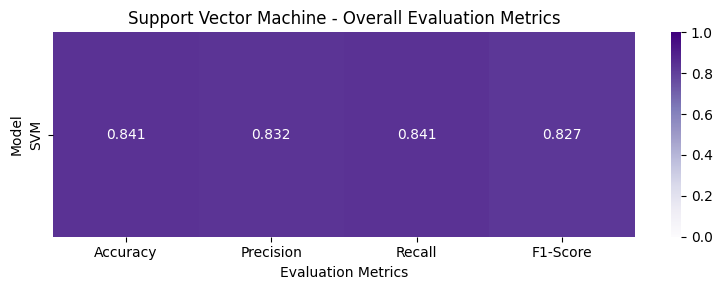

In [111]:
# HeatMap Visualization
plt.figure(figsize=(8, 3))

sns.heatmap(
    svm_metrics,
    annot=True,
    fmt=".3f",
    cmap="Purples",
    vmin=0,
    vmax=1
)

plt.title("Support Vector Machine - Overall Evaluation Metrics")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [113]:
# Comparison Models
results = pd.DataFrame({
    "Model": [
        "Gaussian Naive Bayes",
        "Support Vector Machine"
    ],

    "Accuracy": [
        nb_accuracy,
        svm_accuracy
    ],

    "Precision": [
        nb_precision,
        svm_precision
    ],

    "Recall": [
        nb_recall,
        svm_recall
    ],

    "F1-Score": [
        nb_f1,
        svm_f1
    ]
})

display(
    results.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian Naive Bayes,77.01%,73.00%,77.01%,72.25%
1,Support Vector Machine,84.07%,83.22%,84.07%,82.69%


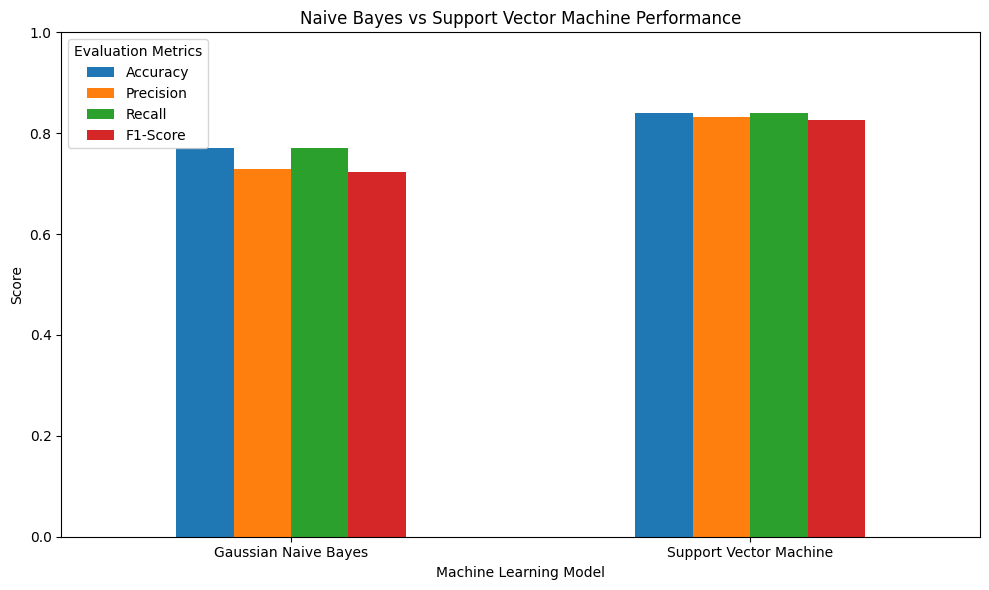

In [114]:
# Visual Comparison of GNB vs SVM
comparison = results.set_index("Model")

comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Naive Bayes vs Support Vector Machine Performance"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metrics"
)

plt.tight_layout()

plt.show()